# Discount Impact Analysis

**Business question:** Do discounts actually make the business money, or do they just inflate revenue while eating profit?

**Dataset:** Sample Superstore (Kaggle) Sales, Discount, Profit, Category, Sub-Category, Region, Segment, Order Date.

---
## Block 1: Setup, cleaning, first look


### Step 2: Load and inspect

In [ ]:
#%pip install scikit-learn

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 725.2 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.2 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.2 MB 1.5 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.2 MB 1.6 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 1.5 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 1.7 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.2 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 1.6 MB/s eta 0:00:04
   -------------- ------------------------- 2.

In [1]:
import pandas as pd
import numpy as np

#Load the Data
df = pd.read_csv(r"data/Sample - Superstore.csv", encoding="latin-1")

#Clean the column names
df.columns = (df.columns.str.strip().str.lower()
              .str.replace(" ", "_").str.replace("-", "_"))
df.shape

(9994, 21)

In [2]:
#Quick Summary of the Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  sub_category   9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  sales          9994 non-null   float64
 18  quantity

In [3]:
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.isna().sum()

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64

### Step 3: Clean and create features

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

df["margin"] = df["profit"] / df["sales"]

bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 0.8]
labels = ["0%", "1-10%", "11-20%", "21-30%", "31-50%", "51-80%"]
df["discount_band"] = pd.cut(df["discount"], bins=bins, labels=labels)

df[["sales", "discount", "profit", "margin", "discount_band"]].head()

Dropped 0 duplicate rows


,sales,discount,profit,margin,discount_band
0,261.9600,0.00,41.9136,0.1600,0%
1,731.9400,0.00,219.5820,0.3000,0%
2,14.6200,0.00,6.8714,0.4700,0%
3,957.5775,0.45,-383.0310,-0.4000,31-50%
4,22.3680,0.20,2.5164,0.1125,11-20%


Quick first-look numbers before moving to Block 2 (profit-by-discount-band, the heatmap, and the break-even point).

In [6]:
loss_making = (df["profit"] < 0).sum()
discounted = (df["discount"] > 0).sum()
n = len(df)

print(f"Rows: {n}")
print(f"Loss-making orders: {loss_making} ({loss_making/n:.1%})")
print(f"Discounted orders: {discounted} ({discounted/n:.1%})")
df["discount_band"].value_counts().sort_index()

Rows: 9994
Loss-making orders: 1871 (18.7%)
Discounted orders: 5196 (52.0%)


discount_band
0%        4798
1-10%       94
11-20%    3709
21-30%     227
31-50%     310
51-80%     856
Name: count, dtype: int64

---
## Block 2: The evidence: what discounts actually do to profit

Block 1 told us two things: **52% of order lines carry a discount** and **18.7% of lines lose money**.
The obvious question is whether those two facts are connected.

In this block we answer it in four steps:
1. Profit and margin by discount band (the summary table)
2. A chart of the same thing
3. A heatmap to check it's not just one product line dragging everything down
4. The **break-even discount**, the point where a discount stops paying for itself

### Step 4: Chart styling (set once, reuse everywhere)

Setting the style once up front keeps every chart consistent.
The colour rule is simple: **blue = making money, red = losing money**. For easy understanding

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})

BLUE = "#2a78d6"   # profit
RED = "#e34948"    # loss
GREY = "#8a8985"   # neutral / reference lines

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

### Step 5: Profit and margin by discount band

We look at **three numbers per band**, because each one on its own can mislead:
- **Total profit**: how many dollars each band actually contributes
- **Margin** (profit / sales): how *efficient* each dollar of revenue is. Total profit alone would favour bands that simply have more orders.
- **Loss rate**: the share of order lines in that band that lose money

We also keep the **row count** so we don't over-read a band with very few orders (the 1-10% band only has 94).

In [11]:
band_summary = (df.groupby("discount_band", observed=True)
                  .agg(orders=("sales", "size"),
                       sales=("sales", "sum"),
                       profit=("profit", "sum"),
                       loss_rate=("profit", lambda s: (s < 0).mean())))

band_summary["margin"] = band_summary["profit"] / band_summary["sales"]
band_summary["share_of_sales"] = band_summary["sales"] / band_summary["sales"].sum()

band_summary.style.format({
    "sales": "${:,.0f}", "profit": "${:,.0f}", "loss_rate": "{:.1%}",
    "margin": "{:.1%}", "share_of_sales": "{:.1%}"
})

,orders,sales,profit,loss_rate,margin,share_of_sales
discount_band,,,,,,
0%,4798,"$1,087,908","$320,988",0.0%,29.5%,47.4%
1-10%,94,"$54,369","$9,029",4.3%,16.6%,2.4%
11-20%,3709,"$792,153","$91,756",14.0%,11.6%,34.5%
21-30%,227,"$103,227","$-10,369",91.6%,-10.0%,4.5%
31-50%,310,"$195,315","$-48,448",91.6%,-24.8%,8.5%
51-80%,856,"$64,229","$-76,559",100.0%,-119.2%,2.8%


**What this tells us:**
- Undiscounted orders earn a **~30% margin** and *none* of them lose money.
- At 11-20% the margin has already dropped to ~12%, still positive but less than half.
- From **21% upward every band loses money in total**, and more than 9 in 10 of those orders are loss-making.
- The 51-80% band is the worst: it loses more than it sells (margin below -100%).

So the relationship isn't "a bit of margin erosion". It's a **cliff**.

### Step 6: Visualising it

Two panels side by side instead of one chart with two y-axes. Dual axes let you make any two lines look related just by
rescaling, so we give each measure its own honest scale.

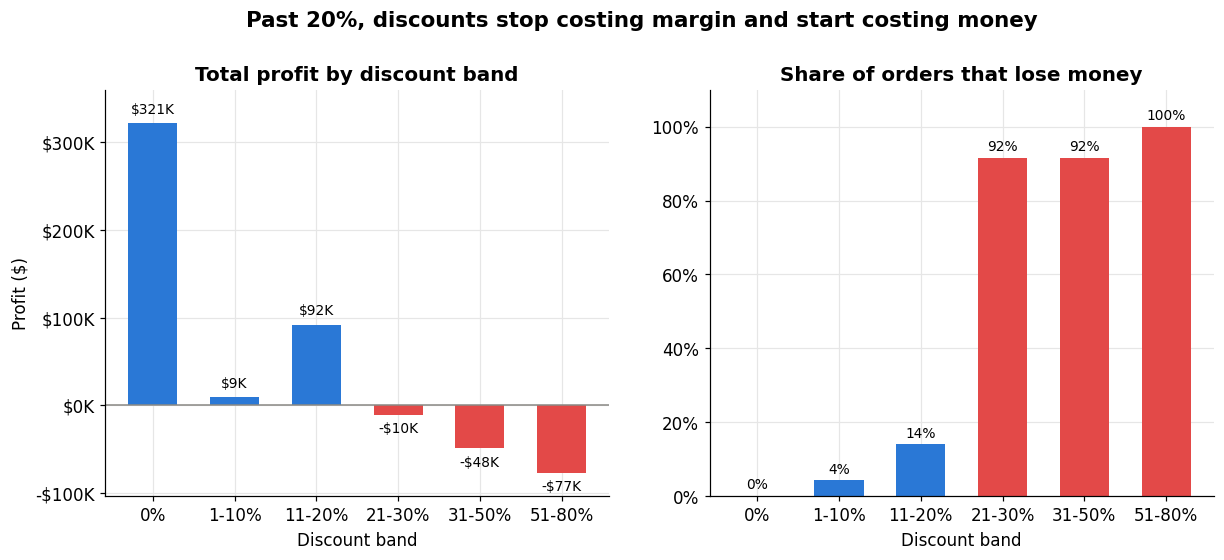

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# left: total profit per band
colors = [BLUE if p >= 0 else RED for p in band_summary["profit"]]
axes[0].bar(band_summary.index.astype(str), band_summary["profit"], color=colors, width=0.6)
axes[0].axhline(0, color=GREY, linewidth=1)
axes[0].set_title("Total profit by discount band")
axes[0].set_xlabel("Discount band")
axes[0].set_ylabel("Profit ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{'-' if x < 0 else ''}${abs(x)/1000:,.0f}K"))
axes[0].set_ylim(band_summary["profit"].min() * 1.35, band_summary["profit"].max() * 1.12)
for i, p in enumerate(band_summary["profit"]):
    axes[0].text(i, p + (8000 if p >= 0 else -8000), f"{'-' if p < 0 else ''}${abs(p)/1000:,.0f}K",
                 ha="center", va="bottom" if p >= 0 else "top", fontsize=9)

# right: share of orders that lose money
colors = [BLUE if r < 0.5 else RED for r in band_summary["loss_rate"]]
axes[1].bar(band_summary.index.astype(str), band_summary["loss_rate"], color=colors, width=0.6)
axes[1].set_title("Share of orders that lose money")
axes[1].set_xlabel("Discount band")
axes[1].set_ylim(0, 1.1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
for i, r in enumerate(band_summary["loss_rate"]):
    axes[1].text(i, r + 0.02, f"{r:.0%}", ha="center", fontsize=9)

fig.suptitle("Past 20%, discounts stop costing margin and start costing money", fontsize=14, fontweight="bold", y=1.03)
plt.savefig(CHARTS / "01_profit_by_discount_band.png")
plt.show()

### Step 7: Is it just one product line? (Sub-category x discount heatmap)

A fair objection to Step 5 would be: *"Maybe the heavy discounts just happen to land on bad products, like Tables."*
If that were true, the problem would be the product, not the discount.

The heatmap tests this. Each cell is the **margin** for one sub-category at one discount band.
If discounting is the cause, we should see margins turning red **left to right across almost every row**, not only in one or two rows.


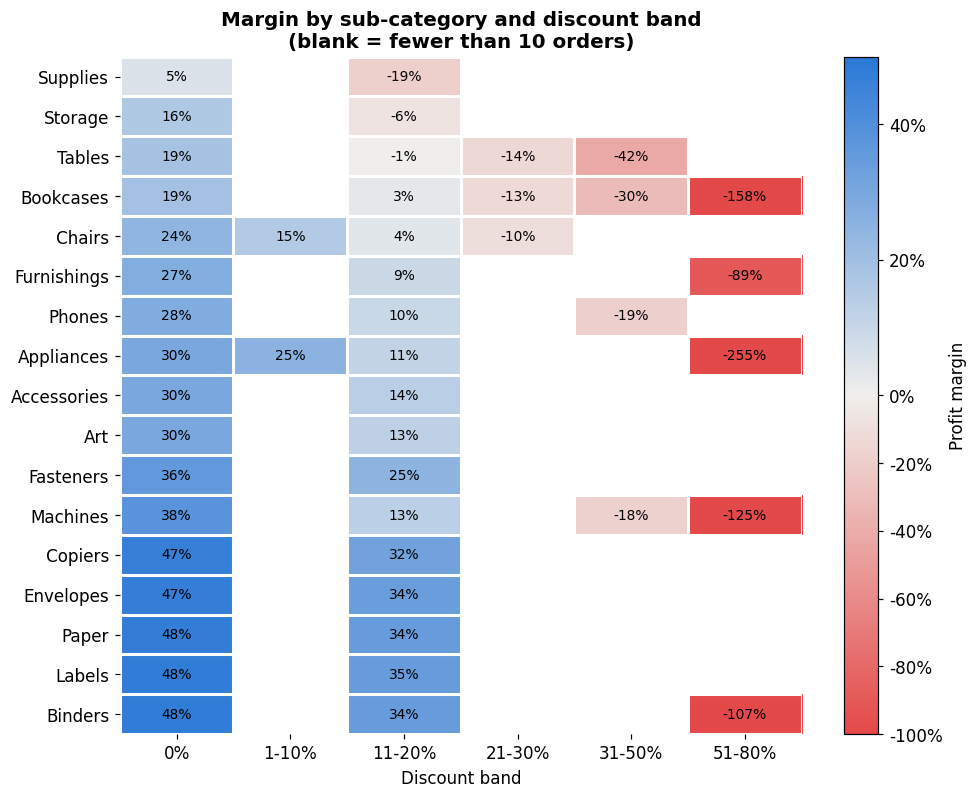

In [14]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

pivot_margin = df.pivot_table(index="sub_category", columns="discount_band",
                              values=["profit", "sales"], aggfunc="sum", observed=False)
margin_grid = pivot_margin["profit"] / pivot_margin["sales"]
count_grid = df.pivot_table(index="sub_category", columns="discount_band",
                            values="sales", aggfunc="size", observed=False).fillna(0)

# sort rows by their undiscounted margin so the most "fragile" products sit at the top
margin_grid = margin_grid.sort_values("0%")
count_grid = count_grid.loc[margin_grid.index]

mask = count_grid < 10

red_grey_blue = LinearSegmentedColormap.from_list("rgb", [RED, "#f0efec", BLUE])
norm = TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=0.5)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(margin_grid.where(~mask).clip(-1, 0.5), cmap=red_grey_blue, norm=norm, aspect="auto")

# write the margin inside each visible cell
for i in range(margin_grid.shape[0]):
    for j in range(margin_grid.shape[1]):
        if not mask.iloc[i, j]:
            ax.text(j, i, f"{margin_grid.iloc[i, j]:.0%}", ha="center", va="center", fontsize=9)

# white gridlines between cells
ax.set_xticks(np.arange(margin_grid.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(margin_grid.shape[0] + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.grid(which="major", visible=False)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(range(margin_grid.shape[1]), margin_grid.columns.astype(str))
ax.set_yticks(range(margin_grid.shape[0]), margin_grid.index)
cbar = fig.colorbar(im, ax=ax, label="Profit margin")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Margin by sub-category and discount band\n(blank = fewer than 10 orders)")
ax.set_xlabel("Discount band")
plt.savefig(CHARTS / "02_margin_heatmap.png")
plt.show()

In [15]:
# How many sub-categories are still profitable at each band? (only counting cells with >= 10 orders)
valid = margin_grid.where(~mask)
pd.DataFrame({
    "sub_categories_with_data": valid.notna().sum(),
    "still_profitable": (valid > 0).sum(),
})

,sub_categories_with_data,still_profitable
discount_band,,
0%,17,17
1-10%,2,2
11-20%,17,14
21-30%,3,0
31-50%,4,0
51-80%,5,0


**Reading the heatmap:** the pattern holds across product lines. Every sub-category with enough data is profitable at 0%,
and not one sub-category with enough data stays profitable past 20% (0 out of 3, 4 and 5 in the three deepest bands).
The product mix is not the explanation; the discount level is.

Notice also that the rows at the top (Supplies, Storage, Tables) start from a thin margin, so they're already in the red at 11-20%,
while high-margin lines like Paper and Binders still make ~34% at that level.
That idea, *"a discount bigger than the product's natural margin is a guaranteed loss"*, becomes a feature in Block 3.

### Step 8: Finding the break-even discount

Bands are handy for communication, but the real discount values in this dataset are a small set of exact levels (0%, 10%, 15%, 20%, 30%...).
Working with the **exact levels** lets us pin down where margin crosses zero.

Approach:
1. Compute margin at each exact discount level
2. Find the first level where margin turns negative
3. Linearly interpolate between that level and the one before it to estimate the break-even point

Interpolation is a simplification (we assume margin falls in a straight line between two observed levels), but it gives the business a practical number to work with instead of "somewhere between 20% and 30%".

In [16]:
by_level = (df.groupby("discount")
              .agg(orders=("sales", "size"), sales=("sales", "sum"), profit=("profit", "sum")))
by_level["margin"] = by_level["profit"] / by_level["sales"]

first_negative = by_level[by_level["margin"] < 0].index.min()
last_positive = by_level.loc[:first_negative].index[-2]

m1 = by_level.loc[last_positive, "margin"]
m2 = by_level.loc[first_negative, "margin"]
break_even = last_positive + (first_negative - last_positive) * m1 / (m1 - m2)

print(f"Last profitable discount level : {last_positive:.0%} (margin {m1:.1%})")
print(f"First loss-making discount level: {first_negative:.0%} (margin {m2:.1%})")
print(f"Estimated break-even discount  : ~{break_even:.0%}")
by_level.style.format({"sales": "${:,.0f}", "profit": "${:,.0f}", "margin": "{:.1%}"})

Last profitable discount level : 20% (margin 11.8%)
First loss-making discount level: 30% (margin -10.0%)
Estimated break-even discount  : ~25%


,orders,sales,profit,margin
discount,,,,
0.000000,4798,"$1,087,908","$320,988",29.5%
0.100000,94,"$54,369","$9,029",16.6%
0.150000,52,"$27,559","$1,419",5.1%
0.200000,3657,"$764,594","$90,337",11.8%
0.300000,227,"$103,227","$-10,369",-10.0%
0.320000,27,"$14,493","$-2,391",-16.5%
0.400000,206,"$116,418","$-23,057",-19.8%
0.450000,11,"$5,485","$-2,493",-45.5%
0.500000,66,"$58,919","$-20,506",-34.8%


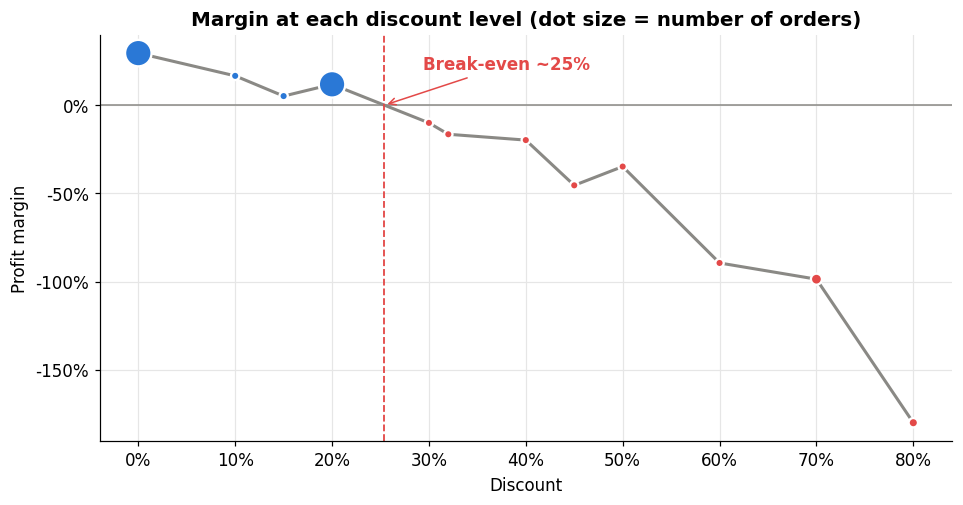

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(by_level.index, by_level["margin"], color=GREY, linewidth=2, zorder=1)
ax.scatter(by_level.index, by_level["margin"],
           c=[BLUE if m >= 0 else RED for m in by_level["margin"]],
           s=np.clip(by_level["orders"] / 8, 30, 300), edgecolor="white", linewidth=1.5, zorder=2)

ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(break_even, color=RED, linestyle="--", linewidth=1.2)
ax.annotate(f"Break-even ~{break_even:.0%}", xy=(break_even, 0), xytext=(break_even + 0.04, 0.2),
            color=RED, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED))

ax.set_title("Margin at each discount level (dot size = number of orders)")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit margin")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.savefig(CHARTS / "03_break_even_discount.png")
plt.show()

### Step 9: But did the discounts at least sell more units?

This is the strongest defence of discounting: *"Sure, margin drops, but we sell more volume."*
If that were true, the lost margin could be buying growth.

Comparing average quantity across bands is a weak test, because different products sit in different bands.
A fairer test is a **like-for-like comparison**: take products that were sold **both with and without** a discount,
and compare the quantity per order line for the *same product*.

We use a **Wilcoxon signed-rank test** for the significance check because the differences are paired (same product) and
quantities are small, skewed counts where a t-test's normality assumption is shaky.

In [18]:
from scipy.stats import wilcoxon

print("Average quantity per order line by band:")
print(df.groupby("discount_band", observed=True)["quantity"].mean().round(2).to_string())

# like-for-like: same product, with vs without discount
df["is_discounted"] = df["discount"] > 0
qty_by_product = (df.groupby(["product_id", "is_discounted"])["quantity"].mean()
                    .unstack()
                    .dropna())
qty_by_product.columns = ["no_discount", "discounted"]
qty_diff = qty_by_product["discounted"] - qty_by_product["no_discount"]

stat, p_value = wilcoxon(qty_by_product["discounted"], qty_by_product["no_discount"])

print(f"\nProducts sold both ways       : {len(qty_by_product):,}")
print(f"Avg qty without discount      : {qty_by_product['no_discount'].mean():.2f}")
print(f"Avg qty with discount         : {qty_by_product['discounted'].mean():.2f}")
print(f"Avg difference (same product) : {qty_diff.mean():+.2f} units")
print(f"Wilcoxon p-value              : {p_value:.3f}")

Average quantity per order line by band:
discount_band
0%        3.81
1-10%     3.97
11-20%    3.74
21-30%    3.74
31-50%    3.80
51-80%    3.91

Products sold both ways       : 1,440
Avg qty without discount      : 3.80
Avg qty with discount         : 3.82
Avg difference (same product) : +0.01 units
Wilcoxon p-value              : 0.908


**Verdict:** the like-for-like comparison shows no meaningful lift in units per order. The difference is a fraction of a unit
and the test doesn't give us grounds to say discounts move volume. Discounts here are **giving away margin without buying extra units**.



---
## Block 3: Feature engineering, turning raw columns into business meaning

The raw data only gives us `sales`, `discount`, `quantity` and `profit`. That's enough to show *that* discounts hurt,
but not enough to explain *how much money* is given away or *which* orders are doomed before they're placed.

Feature engineering lets us rebuild the **unit economics** of each order line. Here's the logic we'll use:

| Feature | Formula | Why we need it |
|---|---|---|
| `list_sales` | sales / (1 - discount) | Revenue at full price, before any discount |
| `discount_amount` | list_sales - sales | Dollars given away on that line |
| `cost` | sales - profit | What the goods cost the business |
| `unit_list_price` | list_sales / quantity | Catalogue price per unit |
| `unit_cost` | cost / quantity | Cost per unit |
| `profit_before_discount` | list_sales - cost | What the line *would* have earned at full price |
| `base_margin` | profit_before_discount / list_sales | The product's natural margin before discounting |

After that we add a **margin headroom** feature, order and time features, and customer-level features.

### Step 10: Rebuild the unit economics

In [19]:
df["ship_date"] = pd.to_datetime(df["ship_date"])

df["list_sales"] = df["sales"] / (1 - df["discount"])
df["discount_amount"] = df["list_sales"] - df["sales"]
df["cost"] = df["sales"] - df["profit"]

df["unit_list_price"] = df["list_sales"] / df["quantity"]
df["unit_cost"] = df["cost"] / df["quantity"]

df["profit_before_discount"] = df["list_sales"] - df["cost"]
df["base_margin"] = df["profit_before_discount"] / df["list_sales"]

df["is_loss"] = (df["profit"] < 0).astype(int)

df[["sales", "discount", "list_sales", "discount_amount", "cost",
    "profit_before_discount", "profit", "base_margin"]].head()

,sales,discount,list_sales,discount_amount,cost,profit_before_discount,profit,base_margin
0,261.9600,0.00,261.96,0.0000,220.0464,41.9136,41.9136,0.16
1,731.9400,0.00,731.94,0.0000,512.3580,219.5820,219.5820,0.30
2,14.6200,0.00,14.62,0.0000,7.7486,6.8714,6.8714,0.47
3,957.5775,0.45,1741.05,783.4725,1340.6085,400.4415,-383.0310,0.23
4,22.3680,0.20,27.96,5.5920,19.8516,8.1084,2.5164,0.29


**Sanity check before we trust these features.** We *derived* list price and cost, so we should confirm they behave like real prices.
If our reconstruction is right, the **same product should always have the same unit list price and unit cost**, no matter what discount it was sold at.
If these numbers jumped around, it would mean our formula is wrong and every insight built on it would be too.

In [20]:
price_check = df.groupby("product_id").agg(
    lines=("sales", "size"),
    list_price_spread=("unit_list_price", lambda s: s.max() - s.min()),
    unit_cost_spread=("unit_cost", lambda s: s.max() - s.min()),
)
multi = price_check[price_check["lines"] > 1]

consistent_price = (multi["list_price_spread"] < 0.01).mean()
consistent_cost = (multi["unit_cost_spread"] < 0.01).mean()
print(f"Products with >1 order line: {len(multi):,}")
print(f"Same unit list price every time: {consistent_price:.1%}")
print(f"Same unit cost every time      : {consistent_cost:.1%}")

Products with >1 order line: 1,771
Same unit list price every time: 98.2%
Same unit cost every time      : 98.2%


For the vast majority of products the unit price and unit cost are identical across every order line, whatever the discount.
That confirms two things:
1. Our reconstructed features are valid.
2. **The discount is a pure price cut.** Cost doesn't change, so every discount dollar comes straight out of profit.

### Step 11: How much money did discounts actually give away?

Now that we have `discount_amount` and `profit_before_discount`, we can put a dollar figure on the whole programme.
This is the number that tends to land in a boardroom: not a percentage, but **dollars handed over**.

In [21]:
total_list = df["list_sales"].sum()
total_sales = df["sales"].sum()
total_discount = df["discount_amount"].sum()
total_profit = df["profit"].sum()
profit_full_price = df["profit_before_discount"].sum()

print(f"Revenue at list price     : ${total_list:,.0f}")
print(f"Discounts given away      : ${total_discount:,.0f}  ({total_discount/total_list:.1%} of list revenue)")
print(f"Actual revenue            : ${total_sales:,.0f}")
print(f"Actual profit             : ${total_profit:,.0f}")
print(f"Profit if sold at list    : ${profit_full_price:,.0f}")
print(f"\nDiscount dollars vs actual profit: {total_discount/total_profit:.1f}x")

# where do the losses come from?
losses = df.loc[df["profit"] < 0, "profit"]
losses_from_deep = df.loc[(df["profit"] < 0) & (df["discount"] > 0.2), "profit"].sum()
print(f"\nTotal losses on loss-making lines: ${losses.sum():,.0f}")
print(f"Share of those losses from discounts above 20%: {losses_from_deep / losses.sum():.1%}")
print(f"Loss-making lines with NO discount: {((df['profit'] < 0) & (df['discount'] == 0)).sum()}")

Revenue at list price     : $2,863,935
Discounts given away      : $566,734  (19.8% of list revenue)
Actual revenue            : $2,297,201
Actual profit             : $286,397
Profit if sold at list    : $853,131

Discount dollars vs actual profit: 2.0x

Total losses on loss-making lines: $-156,131
Share of those losses from discounts above 20%: 88.7%
Loss-making lines with NO discount: 0


This is one of the strongest lines for the post: the business gave away **roughly twice its entire profit** in discounts,
and **not a single undiscounted order lost money**. Every loss in this dataset has a discount attached to it.

### Step 12: Margin headroom, the "doomed before it ships" feature

Here's the key idea. A line loses money when **the discount is larger than the product's natural margin**.
If a product earns 20% at full price and you give 30% off, you're now selling below cost. No volume fixes that.

The problem is that at the moment of sale, a sales rep doesn't know each product's exact cost.
They *can* know a **reference margin** for the sub-category. So we build a practical, policy-ready version:

- `subcat_ref_margin` = the sub-category's margin on **undiscounted** orders only. We use 0%-discount orders because they show the natural margin with no discount contaminating it.
- `margin_headroom` = subcat_ref_margin - discount. Positive means there's room to discount; negative means the discount eats past the margin.
- `discount_exceeds_margin` = 1 when headroom is negative.

In [22]:
undiscounted = df[df["discount"] == 0]
subcat_ref_margin = (undiscounted.groupby("sub_category")["profit"].sum()
                     / undiscounted.groupby("sub_category")["sales"].sum())

df["subcat_ref_margin"] = df["sub_category"].map(subcat_ref_margin)
df["margin_headroom"] = df["subcat_ref_margin"] - df["discount"]
df["discount_exceeds_margin"] = (df["margin_headroom"] < 0).astype(int)

headroom_summary = (df.groupby("discount_exceeds_margin")
                      .agg(orders=("sales", "size"),
                           loss_rate=("is_loss", "mean"),
                           total_profit=("profit", "sum"),
                           discount_given=("discount_amount", "sum")))
headroom_summary.index = ["Discount within margin", "Discount exceeds margin"]
headroom_summary.style.format({"loss_rate": "{:.1%}", "total_profit": "${:,.0f}", "discount_given": "${:,.0f}"})

,orders,loss_rate,total_profit,discount_given
Discount within margin,8109,3.4%,"$431,612","$176,599"
Discount exceeds margin,1885,84.6%,"$-145,215","$390,136"


A single, simple rule splits the data almost perfectly:
- When the discount stays **within** the sub-category's natural margin, only a few percent of lines lose money.
- When the discount **exceeds** it, the large majority lose money and the group as a whole destroys profit.

This is the kind of rule a business can actually put into a pricing system: *"never discount past the reference margin without approval."*

In [23]:
# which sub-categories have the least headroom? (these should get the tightest discount caps)
subcat_view = (df.groupby("sub_category")
                 .agg(ref_margin=("subcat_ref_margin", "first"),
                      avg_discount=("discount", "mean"),
                      pct_lines_over_margin=("discount_exceeds_margin", "mean"),
                      total_profit=("profit", "sum"))
                 .sort_values("ref_margin"))
subcat_view.style.format({"ref_margin": "{:.1%}", "avg_discount": "{:.1%}",
                          "pct_lines_over_margin": "{:.1%}", "total_profit": "${:,.0f}"})

,ref_margin,avg_discount,pct_lines_over_margin,total_profit
sub_category,,,,
Supplies,5.4%,7.7%,38.4%,"$-1,189"
Storage,16.2%,7.5%,37.4%,"$21,279"
Tables,18.5%,26.1%,77.4%,"$-17,725"
Bookcases,19.0%,21.1%,50.9%,"$-3,473"
Chairs,24.1%,17.0%,25.6%,"$26,590"
Furnishings,27.4%,13.8%,14.4%,"$13,059"
Phones,27.7%,15.5%,12.3%,"$44,516"
Appliances,29.7%,16.7%,14.4%,"$18,138"
Accessories,29.8%,7.8%,0.0%,"$41,937"


Look at the three loss-making sub-categories: **Tables, Bookcases and Supplies**.
- Tables and Bookcases have thin natural margins (~19%) yet get some of the *heaviest* average discounts (26% and 21%), so 77% and 51% of their lines go past the margin.
- Supplies has a 5% natural margin, so even the standard 20% discount wipes it out.
- Binders and Machines prove the point from the other side: great natural margins (48% and 38%), but discounts so deep that ~40% of their lines still go past it.

None of these products is broken. The discount policy just ignores each product's margin.

### Step 13: Order and time features

Next we check whether the effect is stable over time or just a one-off period, e.g. a single bad clearance sale.

Features:
- `order_year`, `order_quarter`, `order_month`: calendar features for trend checks
- `days_to_ship`: fulfilment speed (to rule out shipping cost as a hidden driver)
- `items_in_order`: how many lines are in the same order (basket size)

In [24]:
df["order_year"] = df["order_date"].dt.year
df["order_quarter"] = df["order_date"].dt.to_period("Q")
df["order_month"] = df["order_date"].dt.month
df["days_to_ship"] = (df["ship_date"] - df["order_date"]).dt.days
df["items_in_order"] = df.groupby("order_id")["order_id"].transform("size")

yearly = (df.groupby("order_year")
            .agg(avg_discount=("discount", "mean"), sales=("sales", "sum"), profit=("profit", "sum"),
                 lines_over_margin=("discount_exceeds_margin", "mean")))
yearly["margin"] = yearly["profit"] / yearly["sales"]
yearly.style.format({"avg_discount": "{:.1%}", "sales": "${:,.0f}", "profit": "${:,.0f}",
                     "lines_over_margin": "{:.1%}", "margin": "{:.1%}"})

,avg_discount,sales,profit,lines_over_margin,margin
order_year,,,,,
2014,15.8%,"$484,247","$49,544",19.1%,10.2%
2015,15.6%,"$470,533","$61,619",18.9%,13.1%
2016,15.5%,"$609,206","$81,795",18.7%,13.4%
2017,15.6%,"$733,215","$93,439",18.8%,12.7%


In [25]:
# quarter by quarter: when average discount goes up, does margin go down?
quarterly = (df.groupby("order_quarter")
               .agg(avg_discount=("discount", "mean"), sales=("sales", "sum"), profit=("profit", "sum")))
quarterly["margin"] = quarterly["profit"] / quarterly["sales"]

corr = quarterly["avg_discount"].corr(quarterly["margin"])
print(f"Correlation between quarterly avg discount and quarterly margin: {corr:.2f}")

# does fulfilment speed or basket size explain losses instead?
print("\nLoss rate by days to ship:")
print(df.groupby("days_to_ship")["is_loss"].mean().round(3).to_string())
print(f"\nCorrelation of is_loss with discount      : {df['is_loss'].corr(df['discount']):.2f}")
print(f"Correlation of is_loss with days_to_ship  : {df['is_loss'].corr(df['days_to_ship']):.2f}")
print(f"Correlation of is_loss with items_in_order: {df['is_loss'].corr(df['items_in_order']):.2f}")

Correlation between quarterly avg discount and quarterly margin: -0.30

Loss rate by days to ship:
days_to_ship
0    0.185
1    0.176
2    0.177
3    0.164
4    0.210
5    0.187
6    0.172
7    0.185

Correlation of is_loss with discount      : 0.75
Correlation of is_loss with days_to_ship  : 0.00
Correlation of is_loss with items_in_order: 0.00


Two things stand out:
- **The discount policy is baked in, not a one-off.** Every year the average discount sits at ~15.5% and ~19% of lines are discounted past their margin. This is a structural pricing habit, not one bad clearance sale.
- Quarter to quarter, heavier discounting goes with weaker margins (correlation around -0.3: moderate, as expected with only 16 quarters).

Meanwhile `is_loss` has a correlation of **0.75 with discount** but **0.00 with shipping speed and basket size**.
That removes two alternative explanations someone might raise in the comments.

### Step 14: Customer-level features, are discount-driven customers worth it?

So far every row has been an **order line**. But businesses usually justify discounts at the **customer** level:
*"We discount to win and keep customers."* So let's aggregate to one row per customer and ask whether customers who get heavy discounts
are more valuable (more orders, more revenue) or less.

Features per customer:
- `avg_discount`: how discount-dependent the customer is
- `orders`, `lifetime_sales`, `lifetime_profit`: their value to the business
- `discount_tier`: customers split into 4 equal-sized groups (quartiles) by avg discount. Quartiles guarantee each tier has a similar number of customers, so comparisons are fair.

In [26]:
customers = (df.groupby("customer_id")
                .agg(avg_discount=("discount", "mean"),
                     orders=("order_id", "nunique"),
                     lifetime_sales=("sales", "sum"),
                     lifetime_profit=("profit", "sum"),
                     discount_received=("discount_amount", "sum")))

customers["discount_tier"] = pd.qcut(customers["avg_discount"], 4,
                                     labels=["Low", "Medium", "High", "Very high"])

tier_view = (customers.groupby("discount_tier", observed=True)
                      .agg(customers=("orders", "size"),
                           avg_discount=("avg_discount", "mean"),
                           avg_orders=("orders", "mean"),
                           avg_sales=("lifetime_sales", "mean"),
                           avg_profit=("lifetime_profit", "mean"),
                           pct_unprofitable=("lifetime_profit", lambda s: (s < 0).mean())))
tier_view.style.format({"avg_discount": "{:.1%}", "avg_orders": "{:.1f}", "avg_sales": "${:,.0f}",
                        "avg_profit": "${:,.0f}", "pct_unprofitable": "{:.1%}"})

,customers,avg_discount,avg_orders,avg_sales,avg_profit,pct_unprofitable
discount_tier,,,,,,
Low,202,5.5%,5.7,"$3,017",$678,4.0%
Medium,196,12.2%,6.7,"$3,126",$586,8.7%
High,198,18.0%,6.8,"$2,866",$196,19.2%
Very high,197,27.5%,6.1,"$2,576",$-22,46.7%


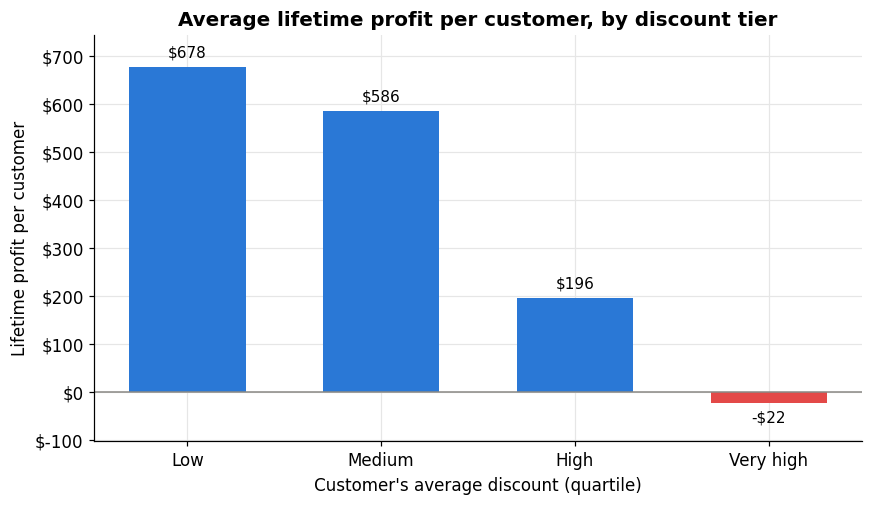

In [27]:
fig, ax = plt.subplots(figsize=(9, 4.8))
profits = tier_view["avg_profit"]
ax.bar(tier_view.index.astype(str), profits, color=[BLUE if p >= 0 else RED for p in profits], width=0.6)
ax.axhline(0, color=GREY, linewidth=1)
for i, p in enumerate(profits):
    ax.text(i, p + (15 if p >= 0 else -15), f"{'-' if p < 0 else ''}${abs(p):,.0f}", ha="center",
            va="bottom" if p >= 0 else "top", fontsize=10)
ax.set_ylim(profits.min() - 80, profits.max() * 1.1)
ax.set_title("Average lifetime profit per customer, by discount tier")
ax.set_xlabel("Customer's average discount (quartile)")
ax.set_ylabel("Lifetime profit per customer")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.savefig(CHARTS / "04_customer_discount_tiers.png")
plt.show()

The most discount-dependent customers **don't place noticeably more orders or spend more** than the rest, yet their lifetime profit is far lower.
The "very high" tier is, on average, **unprofitable**. Discounts aren't buying loyalty here; they're subsidising customers who would buy anyway.

### Step 15: Is it just one region or segment?

One last check before modelling. If all the damage came from, say, one region, the story would be "fix that region", not "fix discounting".

In [28]:
for col in ["region", "segment"]:
    view = (df.groupby(col)
              .agg(avg_discount=("discount", "mean"), sales=("sales", "sum"), profit=("profit", "sum"),
                   loss_rate=("is_loss", "mean")))
    view["margin"] = view["profit"] / view["sales"]
    display(view.sort_values("avg_discount", ascending=False)
                .style.format({"avg_discount": "{:.1%}", "sales": "${:,.0f}", "profit": "${:,.0f}",
                               "loss_rate": "{:.1%}", "margin": "{:.1%}"}))

,avg_discount,sales,profit,loss_rate,margin
region,,,,,
Central,24.0%,"$501,240","$39,706",31.9%,7.9%
South,14.7%,"$391,722","$46,749",16.0%,11.9%
East,14.5%,"$678,781","$91,523",19.4%,13.5%
West,10.9%,"$725,458","$108,418",9.9%,14.9%


,avg_discount,sales,profit,loss_rate,margin
segment,,,,,
Corporate,15.8%,"$706,146","$91,979",18.4%,13.0%
Consumer,15.8%,"$1,161,401","$134,119",19.3%,11.5%
Home Office,14.7%,"$429,653","$60,299",17.5%,14.0%


The ranking is telling: **the region with the highest average discount (Central) has the lowest margin, and the one with the lowest discount (West) has the highest.**
Segments get almost identical average discounts and end up with similar margins, so segment doesn't explain the losses either.
It's a company-wide pricing issue that shows up wherever the discounts are deepest.

### Step 16: Policy simulation, what if discounts were capped?

We can now use our engineered features to answer the question a manager actually cares about: **"What would we have earned with a discount cap?"**

For each line we recompute profit as: `list_sales * (1 - capped_discount) - cost`.

**Key assumption:** volume stays the same after the cap. Step 9 is what gives us the right to make this assumption,
since discounted orders weren't bigger than undiscounted ones for the same product. It's still an assumption, so we treat the result as an
estimate of the size of the opportunity, not a forecast.

In [29]:
caps = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.80]
scenarios = []
for cap in caps:
    capped = df["discount"].clip(upper=cap)
    new_profit = (df["list_sales"] * (1 - capped) - df["cost"]).sum()
    scenarios.append({"discount_cap": cap,
                      "profit": new_profit,
                      "change_vs_actual": new_profit - total_profit,
                      "loss_lines": ((df["list_sales"] * (1 - capped) - df["cost"]) < 0).sum()})

scenarios = pd.DataFrame(scenarios)
scenarios.style.format({"discount_cap": "{:.0%}", "profit": "${:,.0f}", "change_vs_actual": "${:+,.0f}"})

,discount_cap,profit,change_vs_actual,loss_lines
0,0%,"$853,131","$+566,734",9
1,10%,"$675,529","$+389,132",330
2,20%,"$505,588","$+219,191",724
3,30%,"$432,843","$+146,446",1113
4,40%,"$376,550","$+90,152",1194
5,50%,"$340,584","$+54,187",1832
6,80%,"$286,397",$+0,1875


In [30]:
cap20 = scenarios.loc[scenarios["discount_cap"] == 0.20].iloc[0]
print(f"Actual profit             : ${total_profit:,.0f}")
print(f"Profit with a 20% cap     : ${cap20['profit']:,.0f}")
print(f"Uplift                    : ${cap20['change_vs_actual']:,.0f} ({cap20['change_vs_actual']/total_profit:+.0%})")
print(f"Lines affected by the cap : {(df['discount'] > 0.20).sum():,} of {len(df):,} ({(df['discount'] > 0.20).mean():.1%})")

Actual profit             : $286,397
Profit with a 20% cap     : $505,588
Uplift                    : $219,191 (+77%)
Lines affected by the cap : 1,393 of 9,994 (13.9%)


A 20% cap only touches a small slice of orders (the ones above 20%), yet under our same-volume assumption it would lift profit dramatically.
We keep 20% rather than 0% because the 11-20% band was still profitable, and some discounting has commercial uses we can't see in this data
(clearing old stock, matching competitors, closing a large account).

---
## Block 4: Machine learning, can a model confirm the claim?

Everything above is descriptive analysis. A fair critic could still say: *"Maybe discount just travels with other things,
like product type, region or customer segment, and those are the real drivers."*

A machine learning model is a good way to test that, because it gets to see **all** those variables at once and decides for itself what matters.

**The task:** predict whether an order line will lose money (`is_loss`) using only information available **at the moment of sale**.

**The questions we want the model to answer:**
1. Can losses be predicted before the order ships?
2. Which feature does the model rely on most?
3. What happens to the model's performance if we take discount away from it?
4. How does predicted loss risk change as we dial the discount up and down, holding everything else fixed?


### Step 17: Choosing features (and avoiding leakage)

**Data leakage** is when a model is given information it wouldn't have in real life, usually something computed from the answer itself.
It produces great-looking scores that are useless in practice.

So we **exclude**: `profit`, `margin`, `cost`, `unit_cost`, `profit_before_discount`, `base_margin`, `subcat_ref_margin`, `margin_headroom`
and `discount_exceeds_margin`. All of these are calculated from `profit`, which is exactly what we're trying to predict.

We **keep** only what a sales system knows when the order is placed:

| Type | Features |
|---|---|
| Numeric | `discount`, `quantity`, `unit_list_price`, `items_in_order`, `order_month` |
| Categorical | `category`, `sub_category`, `region`, `segment`, `ship_mode` |

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

numeric_features = ["discount", "quantity", "unit_list_price", "items_in_order", "order_month"]
categorical_features = ["category", "sub_category", "region", "segment", "ship_mode"]

X = df[numeric_features + categorical_features]
y = df["is_loss"]

# stratify keeps the ~19% loss rate the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Loss rate in train: {y_train.mean():.1%} | test: {y_test.mean():.1%}")

Train: 7,495 rows | Test: 2,499 rows
Loss rate in train: 18.7% | test: 18.7%


### Step 18: Train two models

We train two very different models on purpose:
- **Logistic regression**: simple, linear and easy to explain. It's our baseline.
- **Random forest**: can capture thresholds and interactions (e.g. *"30% off is fine on Binders but not on Tables"*) that a linear model can't.

If both models tell the same story, the finding doesn't depend on one algorithm's quirks.

Both models sit inside a `Pipeline` together with the preprocessing (one-hot encoding for categories, scaling for numbers).
This guarantees the preprocessing is fitted **only on the training data**, which is another way leakage can sneak in.

In [32]:
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

models = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            class_weight="balanced", random_state=42, n_jobs=-1),
}

fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", make_preprocessor(numeric_features, categorical_features)),
                     ("model", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name] = pipe
    print(f"{name:20s} ROC AUC: {roc_auc_score(y_test, proba):.3f}")

Logistic regression  ROC AUC: 0.986
Random forest        ROC AUC: 0.989


**Why ROC AUC?** Only ~19% of lines are losses, so plain accuracy is misleading: a model that always says "profitable" would score 81% while being useless.
ROC AUC measures how well the model **ranks** risky lines above safe ones. 0.5 is a coin flip and 1.0 is perfect.

`class_weight="balanced"` tells the models to pay extra attention to the rarer loss class instead of just learning to say "profitable".

In [33]:
rf = fitted["Random forest"]
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Profitable", "Loss"]))

cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                  index=["Actual: profitable", "Actual: loss"],
                  columns=["Predicted: profitable", "Predicted: loss"])
cm

              precision    recall  f1-score   support

  Profitable       0.99      0.93      0.96      2031
        Loss       0.76      0.95      0.85       468

    accuracy                           0.94      2499
   macro avg       0.88      0.94      0.90      2499
weighted avg       0.95      0.94      0.94      2499



,Predicted: profitable,Predicted: loss
Actual: profitable,1893,138
Actual: loss,24,444


The model catches the large majority of loss-making lines **before they happen**, using only order-time information.
In business terms, that means losses are not random bad luck. They're predictable, which means they're preventable.

### Step 19: Ablation test, what if the model can't see discount?

This is the most direct test of our claim. We retrain the exact same random forest three ways:
1. **All features** (what we just did)
2. **All features except discount**: the model has product, region, segment, price and so on, but no discount
3. **Discount only**: nothing else

If discount is the real driver, removing it should hurt the model badly, and discount alone should do almost as well as everything together.
If discount were only a stand-in for product or region, the model without it would barely notice.

In [34]:
def rf_auc(num_cols, cat_cols):
    pipe = Pipeline([
        ("prep", make_preprocessor(num_cols, cat_cols)),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                         class_weight="balanced", random_state=42, n_jobs=-1)),
    ])
    pipe.fit(X_train[num_cols + cat_cols], y_train)
    return roc_auc_score(y_test, pipe.predict_proba(X_test[num_cols + cat_cols])[:, 1])

no_discount_num = [c for c in numeric_features if c != "discount"]

ablation = pd.Series({
    "All features": rf_auc(numeric_features, categorical_features),
    "All features EXCEPT discount": rf_auc(no_discount_num, categorical_features),
    "Discount ONLY": rf_auc(["discount"], []),
}, name="ROC AUC").round(3)
ablation.to_frame()

,ROC AUC
All features,0.989
All features EXCEPT discount,0.885
Discount ONLY,0.945


This result is the strongest ML evidence in the notebook:
- **Discount on its own** reaches an AUC of 0.945, close to the full model's 0.989.
- **Remove discount** and AUC drops to 0.885, even though the model still knows the product, region, segment, price and quantity.

Why is 0.885 still decent without discount? Because the other columns partly *stand in* for it: some sub-categories (Binders, Machines, Tables)
and regions (Central) are discounted much more heavily than others, so the model can partly guess the discount from them.
In other words, the other variables mostly matter *through* the discount that gets applied to them.

### Step 20: Which features does the model rely on? (Permutation importance)

Random forests have a built-in `feature_importances_`, but it's known to be biased toward numeric and high-cardinality features.
**Permutation importance** is more trustworthy: we shuffle one feature at a time in the **test set** and measure how much the model's AUC drops.
A big drop means the model genuinely depended on that feature.

Because we permute the raw columns (before one-hot encoding), each categorical variable gets one importance score instead of being split into many dummy columns.

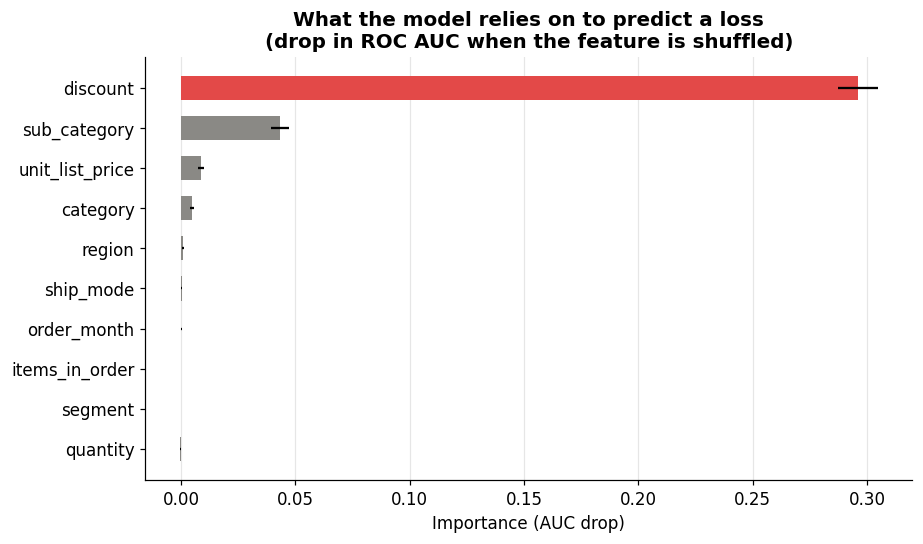

,feature,importance,std
0,discount,0.2959,0.0087
6,sub_category,0.0433,0.0041
2,unit_list_price,0.0087,0.0011
5,category,0.0048,0.0009
7,region,0.0009,0.0004
9,ship_mode,0.0002,0.0002
4,order_month,0.0001,0.0002
3,items_in_order,0.0000,0.0001
8,segment,-0.0001,0.0001
1,quantity,-0.0004,0.0001


In [35]:
perm = permutation_importance(rf, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=42, n_jobs=-1)

importance = (pd.DataFrame({"feature": X_test.columns,
                            "importance": perm.importances_mean,
                            "std": perm.importances_std})
                .sort_values("importance"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance["feature"], importance["importance"], xerr=importance["std"],
        color=[RED if f == "discount" else GREY for f in importance["feature"]], height=0.6)
ax.set_title("What the model relies on to predict a loss\n(drop in ROC AUC when the feature is shuffled)")
ax.set_xlabel("Importance (AUC drop)")
ax.grid(axis="y", visible=False)
plt.savefig(CHARTS / "05_feature_importance.png")
plt.show()

importance.sort_values("importance", ascending=False).round(4)

Discount dominates. `sub_category` comes second, which lines up with the heatmap from Step 7: the same discount hurts some product lines more
because they start from a thinner margin. Region, segment, ship mode and month contribute very little on their own.

### Step 21: What-if analysis, dialling the discount up and down

Last question: **holding everything else about each order fixed, how does loss risk change as the discount changes?**

We take every order in the test set, overwrite its discount with a single value (0%, 10%, 20% ... 80%), and ask the model for the
average probability of a loss. This is the idea behind a **partial dependence plot**, written out by hand so it's clear exactly what's happening.

Because every other column stays the same, any change in predicted risk comes from the discount alone.

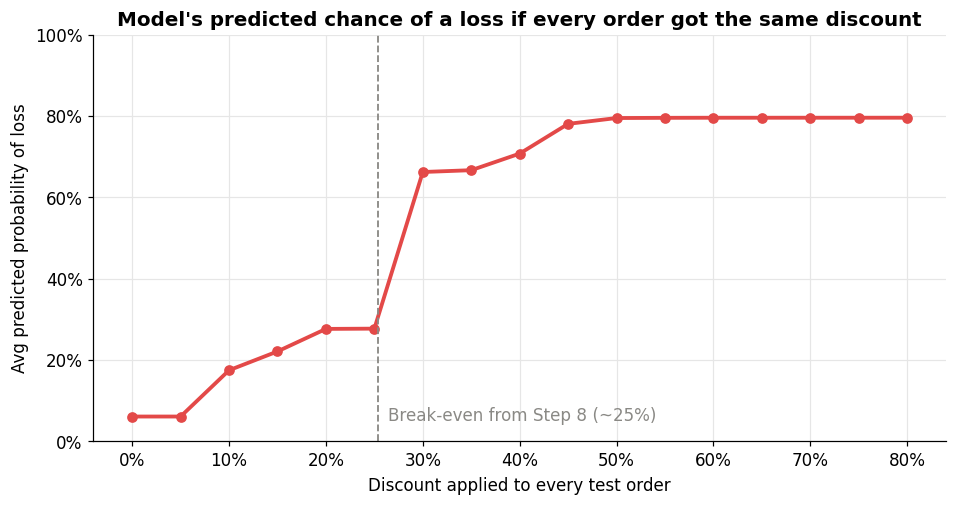

,avg_predicted_loss_probability
0.000000,6.1%
0.050000,6.1%
0.100000,17.4%
0.150000,22.1%
0.200000,27.6%
0.250000,27.7%
0.300000,66.2%
0.350000,66.7%
0.400000,70.7%
0.450000,78.1%


In [36]:
levels = np.round(np.arange(0, 0.81, 0.05), 2)
what_if = []
for d in levels:
    X_temp = X_test.copy()
    X_temp["discount"] = d
    what_if.append(rf.predict_proba(X_temp)[:, 1].mean())

what_if = pd.Series(what_if, index=levels, name="avg_predicted_loss_probability")

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(what_if.index, what_if.values, color=RED, linewidth=2.5, marker="o", markersize=6)
ax.axvline(break_even, color=GREY, linestyle="--", linewidth=1.2)
ax.text(break_even + 0.01, 0.05, f"Break-even from Step 8 (~{break_even:.0%})", color=GREY)
ax.set_title("Model's predicted chance of a loss if every order got the same discount")
ax.set_xlabel("Discount applied to every test order")
ax.set_ylabel("Avg predicted probability of loss")
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.savefig(CHARTS / "06_what_if_discount.png")
plt.show()

what_if.to_frame().style.format("{:.1%}")

The model, trained with no knowledge of our break-even calculation, independently finds the **same tipping point**:
predicted risk creeps up from ~6% to ~28% as the discount goes from 0% to 25%, then **more than doubles to ~66% at 30%**.
The single biggest jump sits right next to the ~25% break-even from Step 8. Two completely different methods, one descriptive and one predictive,
land on the same answer. That agreement is what makes the claim solid.

(The curve flattens after ~50% because random forests can't extrapolate: few products were ever discounted that deeply, so the model just
holds its last estimate. The real data in Step 5 shows 100% of those orders lose money.)

### Limitations (worth stating honestly)
- **Observational data.** The model finds a very strong association; the unit-economics check in Step 10 (discount is a pure price cut on a fixed cost) is what gives it a causal reading.
- **No view of lost customers.** We only see orders that happened, not buyers who might have walked away without a discount.
- **Same-volume assumption** in the cap simulation (Step 16) is supported by Step 9 but not guaranteed.
- **Sample Superstore** is a teaching dataset. The method transfers to real data; the exact numbers won't.

---
## Block 5: Summary (THE NUMBERS)



In [37]:
print("DISCOUNT IMPACT ANALYSIS - KEY NUMBERS")
print("=" * 50)
print(f"Order lines analysed                 : {len(df):,}")
print(f"Lines with a discount                : {df['is_discounted'].mean():.0%}")
print(f"Margin at 0% discount                : {band_summary.loc['0%', 'margin']:.1%}")
print(f"Margin at 11-20% discount            : {band_summary.loc['11-20%', 'margin']:.1%}")
print(f"Loss-making lines with NO discount   : {((df['profit'] < 0) & (df['discount'] == 0)).sum()}")
print(f"Estimated break-even discount        : ~{break_even:.0%}")
print(f"Share of all losses from >20% disc.  : {losses_from_deep / losses.sum():.0%}")
print(f"Discount dollars given away          : ${total_discount:,.0f}")
print(f"Actual profit                        : ${total_profit:,.0f}")
print(f"Extra units per order from discount  : {qty_diff.mean():+.2f}")
print(f"Loss rate when discount > margin     : {df.loc[df['discount_exceeds_margin'] == 1, 'is_loss'].mean():.0%}")
print(f"Profit uplift from a 20% cap (est.)  : ${cap20['change_vs_actual']:,.0f} ({cap20['change_vs_actual']/total_profit:+.0%})")
print(f"ML - AUC with all features           : {ablation['All features']:.3f}")
print(f"ML - AUC without discount            : {ablation['All features EXCEPT discount']:.3f}")
print(f"ML - AUC with discount only          : {ablation['Discount ONLY']:.3f}")

DISCOUNT IMPACT ANALYSIS - KEY NUMBERS
Order lines analysed                 : 9,994
Lines with a discount                : 52%
Margin at 0% discount                : 29.5%
Margin at 11-20% discount            : 11.6%
Loss-making lines with NO discount   : 0
Estimated break-even discount        : ~25%
Share of all losses from >20% disc.  : 89%
Discount dollars given away          : $566,734
Actual profit                        : $286,397
Extra units per order from discount  : +0.01
Loss rate when discount > margin     : 85%
Profit uplift from a 20% cap (est.)  : $219,191 (+77%)
ML - AUC with all features           : 0.989
ML - AUC without discount            : 0.885
ML - AUC with discount only          : 0.945


### Key takeaways

1. **Discounts inflate revenue, not profit.** Margin falls from ~30% at full price to ~12% at 11-20%, and every band above 20% loses money in total.
2. **Every single loss has a discount attached.** Zero undiscounted order lines lost money; 89% of all losses come from discounts above 20%.
3. **The break-even is ~25%.** Found once from the data (Step 8) and again, independently, by the model (Step 21).
4. **Discounts didn't buy volume.** The same product sold with a discount moved +0.01 units per order, statistically nothing.
5. **They didn't buy better customers either.** The most discount-dependent quarter of customers is, on average, unprofitable.
6. **One engineered feature does most of the work.** A discount bigger than the product's natural margin loses money 85% of the time.
7. **The fix is simple.** Capping discounts at 20% touches only ~14% of orders and, if volume holds, would have added roughly $219K (+77%) to profit.

**The one-line version for the post:** *the business gave away $567K in discounts to earn $286K in profit, and discount alone predicts which orders will lose money with 0.95 AUC.*

## I am OFOR CHUKWUEBUKA EMMANUEL

### Check me out on 
### https://www.linkedin.com/in/ebuka-enterprises?utm_source=share_via&utm_content=profile&utm_medium=member_ios